# Predictability of the 2021 PNW heatwave

Ensemble maximum 2 m temperature over 27-30 June against ERA5, the ensemble-mean
2 m temperature bias against ERA5 on 29 June, and the same bias in total column
water vapour on 25 June.

In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import warnings
from cmcrameri import cm
import cfgrib

import babet as bb
import atmicp

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
atmicp.style.set_style()

# climate scenario colours from the shared style
CLIM = {'pi': atmicp.style.climate_color('1870'),        # blue
        'curr': atmicp.style.climate_color('present'),   # grey
        'incr': atmicp.style.climate_color('future1')}   # orange

LABEL = {'pi': 'pre-industrial', 'curr': 'current', 'incr': 'increased'}

# one linestyle per perturbation, so climate stays the only thing colour encodes
LS = {'iterated': '-',
      'iterated_short': ':',
      'tq': '--',
      'ocean': '-.',
      'none': '-'}

PERT_LABEL = {'iterated': 'iterated',
              'iterated_short': 'iterated, short',
              'tq': 'delta t+q',
              'ocean': 'ocean only',
              'none': 'unperturbed'}

# Import data

`get_ifs_data` loads the 18/22/26 June initialisations of the iterated run set.
Experiments that have not been retrieved yet are skipped with a warning.

In [3]:
ifs = atmicp.Data.get_ifs_data(levtype='sfc', res='US025')
ifs

Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vj (pi, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(
/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vr (pi, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(


Loading 3 file(s) for b2vl (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2vo (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
Loading 3 file(s) for b2vo (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2ut (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/cf
Loading 3 file(s) for b2ut (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/pf
Loading 3 file(s) for b2vm (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf


/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vk (incr, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(
/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vq (incr, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(


Loading 3 file(s) for b2vm (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf
Loading 3 file(s) for b2vn (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf
Loading 3 file(s) for b2vn (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf


<xarray.Dataset> Size: 112GB
Dimensions:       (climate: 3, perturbation: 3, time: 105, number: 51,
                   inidate: 3, latitude: 161, longitude: 201)
Coordinates:
  * climate       (climate) object 24B 'pi' 'curr' 'incr'
  * perturbation  (perturbation) object 24B 'none' 'ocean' 'tq'
  * time          (time) datetime64[ns] 840B 2021-06-18 ... 2021-07-01
  * number        (number) int64 408B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * inidate       (inidate) datetime64[ns] 24B 2021-06-18 2021-06-22 2021-06-26
  * latitude      (latitude) float32 644B 70.0 69.75 69.5 ... 30.5 30.25 30.0
  * longitude     (longitude) float32 804B -150.0 -149.8 ... -100.2 -100.0
Data variables:
    t2m           (climate, perturbation, time, number, inidate, latitude, longitude) float64 37GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
    msl           (climate, perturbation, time, number, inidate, latitude, longitude) float64 37GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
    tcwv          (climate, perturbation, time, number, inidate, latitude, longitude) float64 37GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2026-08-17 10:16:16 GMT by grib_to_netcdf-2.47.1: /opt/ecmw...

In [4]:
# hourly ERA5 t2m on the same grid and domain as the IFS retrievals
era5 = atmicp.Data.get_era5_sfc(var='t2m')
era5

<xarray.Dataset> Size: 93MB
Dimensions:    (time: 720, latitude: 161, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-06-01 ... 2021-06-30T23:00:00
  * latitude   (latitude) float64 1kB 70.0 69.75 69.5 69.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -150.0 -149.8 -149.5 ... -100.2 -100.0
Data variables:
    t2m        (time, latitude, longitude) float32 93MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-19T14:11 GRIB to CDM+CF via cfgrib-0.9.1...

# ECDF of maximum 2m temperature, 27-30 June

Area-averaged over the PNW box, then the maximum over the window for each
ensemble member. ERA5 is a single value rather than a distribution, so it is
drawn as a dashed vertical line.

In [5]:
pnw = atmicp.Constants.pnw
box = dict(longitude=slice(pnw[0], pnw[1]), latitude=slice(pnw[3], pnw[2]))
window = slice('2021-06-27', '2021-06-30T23')

# per-member maximum over the window, area-averaged over the PNW box
tmax = (ifs.t2m.sel(**box).mean(['latitude', 'longitude'])
        .sel(time=window).max('time').compute() - 273.15)

era5_tmax = float(era5.t2m.sel(**box).mean(['latitude', 'longitude'])
                  .sel(time=window).max('time') - 273.15)

print(f'ERA5 max t2m over the PNW box, 27-30 June: {era5_tmax:.2f} degC')

ERA5 max t2m over the PNW box, 27-30 June: 38.51 degC


In [6]:
# which (climate, perturbation) combinations actually ran? the concat NaN-fills
# the rest, and this is cheap now that tmax is a small array
present = [(str(c), str(p))
           for c in ifs.climate.values for p in ifs.perturbation.values
           if bool(tmax.sel(climate=c, perturbation=p).notnull().any())]
present

[('pi', 'ocean'),
 ('pi', 'tq'),
 ('curr', 'none'),
 ('incr', 'ocean'),
 ('incr', 'tq')]

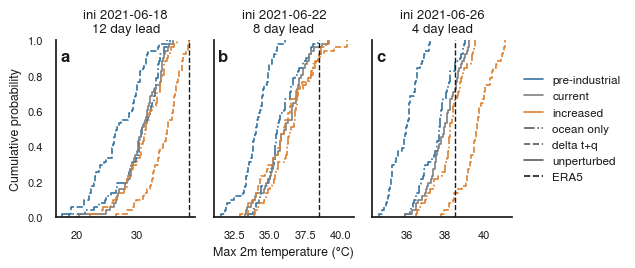

In [7]:
ncol = len(tmax.inidate)

# drawn on the style.py reference canvas, so the sizes quoted there are the
# sizes the figure prints at; scaled() keeps that true if the canvas changes
fig = plt.figure(figsize=(atmicp.style.REF_WIDTH, 2.3))
gs = fig.add_gridspec(1, ncol + 1, width_ratios=[1] * ncol + [0.6], wspace=0.15)

axes = []
for i, inidate in enumerate(tmax.inidate.values):
    # shared y only: each lead time keeps its own temperature range
    ax = fig.add_subplot(gs[0, i], sharey=axes[0] if axes else None)
    axes.append(ax)

    for climate, pert in present:
        da = tmax.sel(inidate=inidate, climate=climate, perturbation=pert).dropna('number')
        if da.size == 0:
            continue
        sns.ecdfplot(x=da.values, color=CLIM[climate], linestyle=LS[pert],
                     linewidth=1.2, ax=ax)

    ax.axvline(era5_tmax, color=atmicp.style.INK, linestyle='--', linewidth=1.0, zorder=10)

    lead = (pd.Timestamp('2021-06-30') - pd.Timestamp(inidate)).days
    ax.set_title(f'ini {np.datetime_as_string(inidate, unit="D")}\n{lead} day lead',
                 fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig))
    # one x label under the middle panel, one y label on the left
    ax.set_xlabel('Max 2m temperature (°C)' if i == ncol // 2 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))
    ax.set_ylabel('Cumulative probability' if i == 0 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))
    ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_TICK, fig),
                   labelleft=(i == 0))
    sns.despine(ax=ax)

atmicp.style.panel_labels(axes)

# legend panel
handles = [Line2D([0], [0], color=CLIM[c], label=LABEL[c])
           for c in ['pi', 'curr', 'incr'] if c in ifs.climate.values]
handles += [Line2D([0], [0], color=atmicp.style.MUTED, linestyle=LS[p], label=PERT_LABEL[p])
            for p in dict.fromkeys(p for _, p in present)]
handles += [Line2D([0], [0], color=atmicp.style.INK, linestyle='--', label='ERA5')]
for h in handles:
    h.set_linewidth(1.2)

ax_legend = fig.add_subplot(gs[0, -1])
ax_legend.axis('off')
ax_legend.legend(handles=handles, loc='center', frameon=False,
                 fontsize=atmicp.style.scaled(atmicp.style.FS_ANNOT, fig),
                 handlelength=1.6, labelspacing=0.5)

atmicp.style.save(fig, '08_ecdf_tmax_pnw')
plt.show()

# Bias maps against ERA5

`bias_map_grid` draws one row per (climate, perturbation) and one column per
initialisation date, so the two bias figures below stay identical apart from
the field, the date and the colour ramp.

In [12]:
def bias_map_grid(bias, vlim, cbar_label, title, stem, cmap=cm.vik):
    """Grid of ensemble-mean bias maps against ERA5.

    One row per (climate, perturbation) in `present`, one column per inidate in
    `bias`. Sizes come from atmicp.style: the canvas is at most the reference
    width and the panel height follows the aspect of the plotted domain.
    """
    inidates = bias.inidate.values
    rows = [(c, p) for c, p in present
            if bool(bias.sel(climate=c, perturbation=p).notnull().any())]
    ncol, nrow = len(inidates), len(rows)

    lon0, lon1, lat0, lat1 = atmicp.Constants.west_coast
    # a grid with fewer than three columns keeps the panel size of a
    # three-column one rather than stretching to the reference width; scaled()
    # then sets the type for the narrower canvas
    panel_w = atmicp.style.REF_WIDTH / max(ncol, 3)
    panel_h = panel_w * (lat1 - lat0) / (lon1 - lon0)

    fig = plt.figure(figsize=(panel_w * ncol, panel_h * nrow + 0.9))
    gs = gridspec.GridSpec(nrow, ncol, wspace=0.06, hspace=0.08,
                           top=0.94, bottom=0.08)

    axes = []
    for r, (climate, pert) in enumerate(rows):
        for c, inidate in enumerate(inidates):
            ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
            axes.append(ax)
            ax.set_extent(atmicp.Constants.west_coast, crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE.with_scale('50m'), color='gray',
                           linewidth=0.5, zorder=14)

            da = bias.sel(climate=climate, perturbation=pert, inidate=inidate)
            mesh = ax.pcolormesh(da.longitude, da.latitude, da,
                                 cmap=cmap, vmin=-vlim, vmax=vlim,
                                 transform=ccrs.PlateCarree())

            # the PNW box the ECDF above averages over
            ax.add_patch(patches.Rectangle(
                (pnw[0], pnw[2]), pnw[1] - pnw[0], pnw[3] - pnw[2],
                linewidth=1.0, edgecolor='white', facecolor='none',
                transform=ccrs.PlateCarree(), zorder=17))

            if r == 0:
                ax.set_title(f'ini {np.datetime_as_string(inidate, unit="D")}',
                             fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))
            if c == 0:
                # far enough out that the second line clears the panel edge
                ax.text(-0.12, 0.5, f'{LABEL[climate]}\n{PERT_LABEL[pert]}',
                        transform=ax.transAxes, rotation=90, va='center', ha='center',
                        fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig),
                        color=CLIM[climate], zorder=20)

    # panel labels a, b, c ... with a white halo, so they stay legible over the
    # dark ends of the colour ramp
    atmicp.style.panel_labels(
        axes, x=0.04, y=0.96,
        path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])

    cbar = fig.colorbar(mesh, ax=fig.axes, orientation='horizontal',
                        fraction=0.025, pad=0.03, shrink=0.5, extend='both')
    cbar.set_label(cbar_label, fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))
    cbar.ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig))

    fig.suptitle(title, fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig), y=0.975)

    atmicp.style.save(fig, stem)
    # plt.show()
    return fig

## 2 m temperature, 29 June

Ensemble-mean daily-mean field minus ERA5, over the full retrieved domain. ERA5
is subsampled onto the IFS 3-hourly timesteps first, so the two daily means
average the same points of the diurnal cycle.

In [13]:
day = '2021-06-29'

ifs_29 = ifs.t2m.sel(time=day)
era5_29 = era5.t2m.sel(time=ifs_29.time)

# grids match exactly, so this differences without regridding
assert np.array_equal(ifs.latitude.values, era5.latitude.values)
assert np.array_equal(ifs.longitude.values, era5.longitude.values)

bias = (ifs_29.mean('time').mean('number') - era5_29.mean('time')).compute()

# a couple of extreme grid points would otherwise flatten the whole colour scale
vmax = float(np.nanmax(np.abs(bias)))
vlim = float(np.ceil(np.nanpercentile(np.abs(bias), 99)))
print(f'max |bias|: {vmax:.2f} K, 99th percentile: {vlim:.0f} K (used for the colour scale)')

max |bias|: 17.34 K, 99th percentile: 12 K (used for the colour scale)


/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

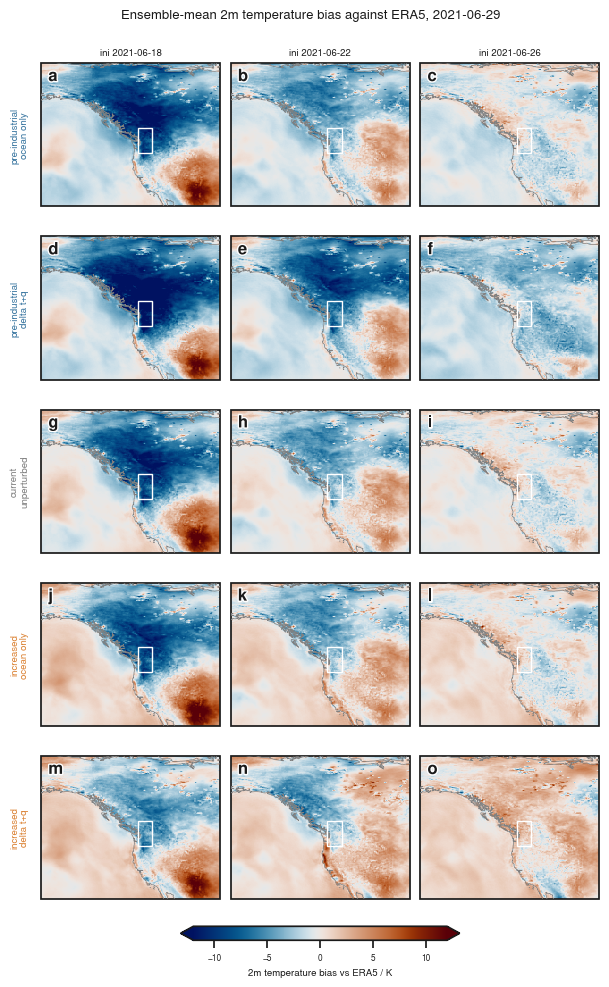

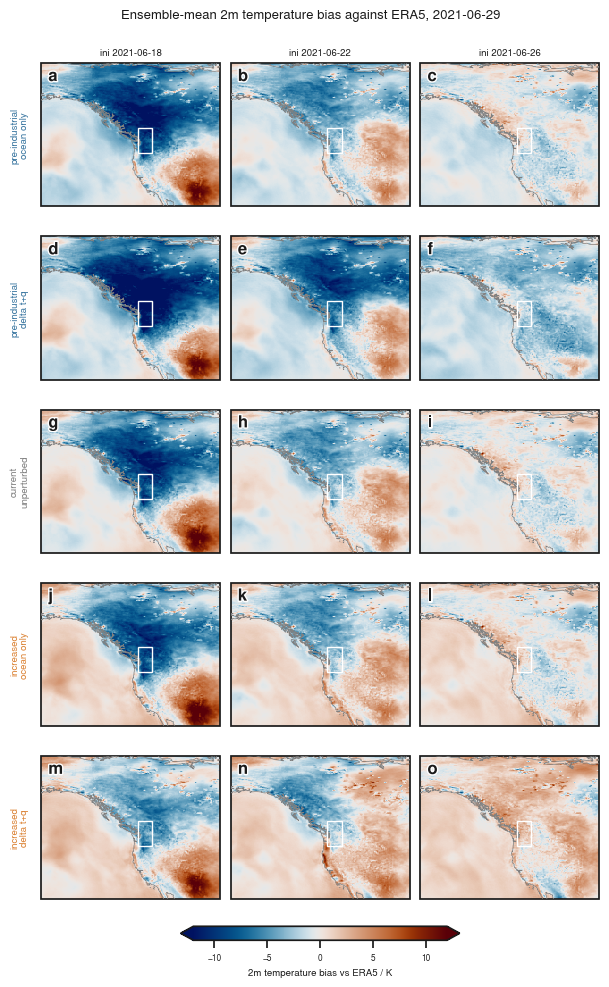

In [14]:
bias_map_grid(bias, vlim,
              cbar_label='2m temperature bias vs ERA5 / K',
              title=f'Ensemble-mean 2m temperature bias against ERA5, {day}',
              stem='08_bias_map_t2m_20210629')

## Total column water vapour, 25 June

The moisture bias four days before the peak of the heatwave, on the same
domain and with the same layout as the temperature bias above.

In [11]:
day_tcwv = '2021-06-25'

# hourly ERA5 tcwv on the same grid and domain as the IFS retrievals
era5_tcwv = atmicp.Data.get_era5_sfc(var='tcwv')

ifs_25 = ifs.tcwv.sel(time=day_tcwv)
era5_25 = era5_tcwv.tcwv.sel(time=ifs_25.time)

assert np.array_equal(ifs.latitude.values, era5_tcwv.latitude.values)
assert np.array_equal(ifs.longitude.values, era5_tcwv.longitude.values)

bias_tcwv = (ifs_25.mean('time').mean('number') - era5_25.mean('time')).compute()

# an initialisation later than this day has nothing to show for it
have = [d for d in bias_tcwv.inidate.values
        if bool(bias_tcwv.sel(inidate=d).notnull().any())]
bias_tcwv = bias_tcwv.sel(inidate=have)

vmax_tcwv = float(np.nanmax(np.abs(bias_tcwv)))
vlim_tcwv = float(np.ceil(np.nanpercentile(np.abs(bias_tcwv), 99)))
print(f'inidates with data on {day_tcwv}: '
      f'{[np.datetime_as_string(d, unit="D") for d in bias_tcwv.inidate.values]}')
print(f'max |bias|: {vmax_tcwv:.2f} kg m-2, 99th percentile: {vlim_tcwv:.0f} kg m-2 '
      f'(used for the colour scale)')

FileNotFoundError: No ERA5 tcwv file at /gf5/predict/AWH019_ERMIS_ATMICP/DATA/ERA5/tcwv_hourly/tcwv_hourly_ERA5_0.25x0.25_202106.nc. Run scripts/era5_download_sfc_hourly.py tcwv (or submit scripts/era5_download_sfc_hourly.sh) to retrieve it.

In [ ]:
# broc reversed: olive where the forecast is too dry, blue where it is too moist
bias_map_grid(bias_tcwv, vlim_tcwv, cmap=cm.broc_r,
              cbar_label='Total column water vapour bias vs ERA5 / kg m$^{-2}$',
              title=f'Ensemble-mean total column water vapour bias against ERA5, {day_tcwv}',
              stem='08_bias_map_tcwv_20210625')